In [17]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from logic.database import AA_PROPERTIES, AA_CLASS, ALPHA, BETA, GAMMA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


### Rebuild linkage matrix (same as 09_clustering)

In [18]:
AA_VOLUME_CLASS = {
    'G': 'very_small', 'A': 'very_small', 'S': 'very_small',
    'T': 'small', 'C': 'small', 'P': 'small', 'D': 'small', 'N': 'small',
    'V': 'medium', 'H': 'medium', 'E': 'medium', 'Q': 'medium',
    'I': 'large', 'L': 'large', 'M': 'large', 'K': 'large', 'R': 'large',
    'F': 'very_large', 'W': 'very_large', 'Y': 'very_large',
}

In [19]:
amino_acids = list(AA_PROPERTIES.keys())

df_props = pd.DataFrame({
    'volume':       [AA_PROPERTIES[aa]['volume']        for aa in amino_acids],
    'hydrophobicity': [AA_PROPERTIES[aa]['hydrophobicity'] for aa in amino_acids],
    'charge':        [AA_PROPERTIES[aa]['charge']        for aa in amino_acids],
}, index=amino_acids)

df_weighted = pd.DataFrame({
    'volume':        2 * df_props['volume'],
    'charge':        1  * df_props['charge'],
    'hydrophobicity': 0.5 * df_props['hydrophobicity'],
}, index=amino_acids)

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df_props.values)
X_weighted = np.column_stack([
    2 * df_props['volume'].values,        # 80 * volume
    1  * df_props['charge'].values,        # 20 * charge
    0.5* df_props['hydrophobicity'].values # 15 * hydrophobicity
])
linkage_matrix = linkage(X_weighted, method='ward')
print("Linkage matrix built.")

Linkage matrix built.


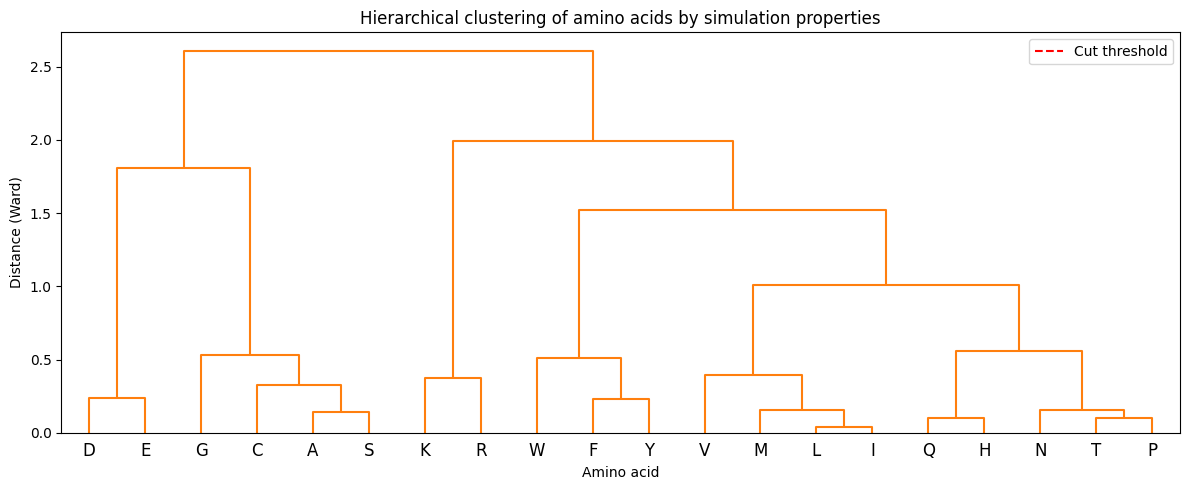

Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['G', 'A', 'S', 'C']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 2 classes: ['nonpolar', 'nonpolar', 'polar', 'polar']
Cluster 2 volume classes: ['very_small', 'very_small', 'very_small', 'small']
----------------------------------------------------------------
Cluster 3: ['K', 'R']
K: class=positive, volume_class=large
R: class=positive, volume_class=large
Cluster 3 classes: ['positive', 'positive']
Cluster 3 volume classes: ['large', 'large']
----------------------------------------------------------------
Cluster 4: ['F', 'Y', 'W']
F: class=nonpolar, volume_class=very_large
Y: class=polar, volume_cla

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 7 # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


### Load pre-extracted window features

### Load full training pool and fixed test set

In [13]:
all_train = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
test_base_raw = pd.read_csv('../data/randomcontrol_feature_by_cluster.csv')
print(f"Training pool: {all_train['trace_id'].nunique()} traces, {len(all_train)} rows")
print(f"Fixed test set: {test_base_raw['trace_id'].nunique()} traces, {len(test_base_raw)} rows")

Training pool: 10000 traces, 199981 rows
Fixed test set: 2000 traces, 39998 rows


### Define models, feature columns, and CV strategy

In [14]:
feature_cols = [
    'mean_minus2',
    'mean_minus1',
    'mean_current',
    'mean_plus1',
    'mean_plus2',
]

models = {
    'GaussianNB': GaussianNB(),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'macro_f1':    'f1_macro',
    'weighted_f1': 'f1_weighted',
    'accuracy':    'accuracy',
}

In [28]:
LABEL_MAP = {
    4: {
        1: '1, negative',
        2: '2, small',
        3: '3, positive',
        4: '4, other'
        },
    5: {
        1: '1, negative',
        2: '2, small',
        3: '3, positive',
        4: '4, large',
        5: '5, other'
        },
    6: {
        1: '1, negative',
        2: '2, small',
        3: '3, positive',
        4: '4, very large',
        5: '5, nonpolar',
        6: '6, medium-small'
    },
    7: {
        1: '1, negative',
        2: '2, small',
        3: '3, positive',
        4: '4, very large',
        5: '5, nonpolar',
        6: '6, medium',
        7: '7, small and nonpolar?'
    }
}

In [29]:
COLOR_MAP = {
    4: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red'
    },
    5: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple'
    },
    6: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple',
        6: 'brown'
    },
    7: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple',
        6: 'brown',
        7: 'cyan'
    }
}

### Sweep over n_traces × n_clusters — fixed test set evaluation

In [30]:
from sklearn.base import clone
from sklearn.metrics import f1_score

TRACE_COUNTS  = [100, 250, 500, 1000, 2000, 5000, 8000, 10000]
CLUSTER_RANGE = range(4, 8)

results   = []
memberships = {}

for n_clusters in CLUSTER_RANGE:
    raw_labels   = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    label_lookup = LABEL_MAP.get(n_clusters, {})
    aa_to_cluster = {
        aa: label_lookup.get(int(raw_labels[i]), f'cluster_{raw_labels[i]}')
        for i, aa in enumerate(amino_acids)
    }

    memberships[n_clusters] = (
        pd.DataFrame({'AA': amino_acids,
                      'cluster': [aa_to_cluster[aa] for aa in amino_acids]})
        .sort_values('cluster')
        .reset_index(drop=True)
    )

    # Build fixed test set once per cluster config
    test_df = test_base_raw.copy()
    test_df['cluster_label'] = test_df['amino_acid'].map(aa_to_cluster)
    X_test = test_df[feature_cols].values
    y_test = test_df['cluster_label'].values
    test_mask = ~np.isnan(X_test).any(axis=1)
    X_test, y_test = X_test[test_mask], y_test[test_mask]

    for n_traces in TRACE_COUNTS:
        train_df = all_train[all_train['trace_id'] < n_traces].copy()
        train_df['cluster_label'] = train_df['amino_acid'].map(aa_to_cluster)
        X_train = train_df[feature_cols].values
        y_train = train_df['cluster_label'].values
        train_mask = ~np.isnan(X_train).any(axis=1)
        X_train, y_train = X_train[train_mask], y_train[train_mask]

        for model_name, model in models.items():
            m = clone(model)
            m.fit(X_train, y_train)
            y_pred = m.predict(X_test)
            results.append({
                'n_traces':    n_traces,
                'n_clusters':  n_clusters,
                'model':       model_name,
                'accuracy':    (y_pred == y_test).mean(),
                'macro_f1':    f1_score(y_test, y_pred, average='macro'),
                'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
            })

    print(f"n_clusters={n_clusters} done.")

results_df = pd.DataFrame(results)
print(results_df)



n_clusters=4 done.
n_clusters=5 done.
n_clusters=6 done.
n_clusters=7 done.
    n_traces  n_clusters               model  accuracy  macro_f1  weighted_f1
0        100           4          GaussianNB  0.549722  0.407632     0.545667
1        100           4  LogisticRegression  0.541190  0.517133     0.559563
2        100           4        RandomForest  0.639634  0.397141     0.593007
3        250           4          GaussianNB  0.545628  0.411193     0.544465
4        250           4  LogisticRegression  0.561191  0.531557     0.580164
..       ...         ...                 ...       ...       ...          ...
91      8000           7  LogisticRegression  0.471373  0.469417     0.463866
92      8000           7        RandomForest  0.440465  0.399574     0.426440
93     10000           7          GaussianNB  0.302300  0.238188     0.266017
94     10000           7  LogisticRegression  0.472248  0.470331     0.464754
95     10000           7        RandomForest  0.440371  0.399698  

In [15]:
# with pd.option_context('display.max_rows', None):
#     display(results_df)

In [31]:
pd.set_option('display.max_rows', None)
results_df.sort_values(['weighted_f1'], ascending=False)

,n_traces,n_clusters,model,accuracy,macro_f1,weighted_f1
23,10000,4,RandomForest,0.671136,0.444718,0.632464
20,8000,4,RandomForest,0.670167,0.444737,0.631398
17,5000,4,RandomForest,0.666698,0.439492,0.627215
14,2000,4,RandomForest,0.661510,0.431517,0.620980
11,1000,4,RandomForest,0.651853,0.426019,0.612630
8,500,4,RandomForest,0.646009,0.420869,0.606378
5,250,4,RandomForest,0.642103,0.412713,0.601732
16,5000,4,LogisticRegression,0.582193,0.547528,0.601351
19,8000,4,LogisticRegression,0.581755,0.546989,0.600919
22,10000,4,LogisticRegression,0.581380,0.546312,0.600587


### Summary plot — performance vs n_traces, coloured by n_clusters

In [32]:
TRACE_COUNTS  = [100, 250, 500, 1000, 2000, 5000, 8000, 10000]
CLUSTER_RANGE = range(4, 8)

metrics     = [('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]
model_names = list(models.keys())
cluster_colors = {n: plt.cm.tab10(i) for i, n in enumerate(CLUSTER_RANGE)}


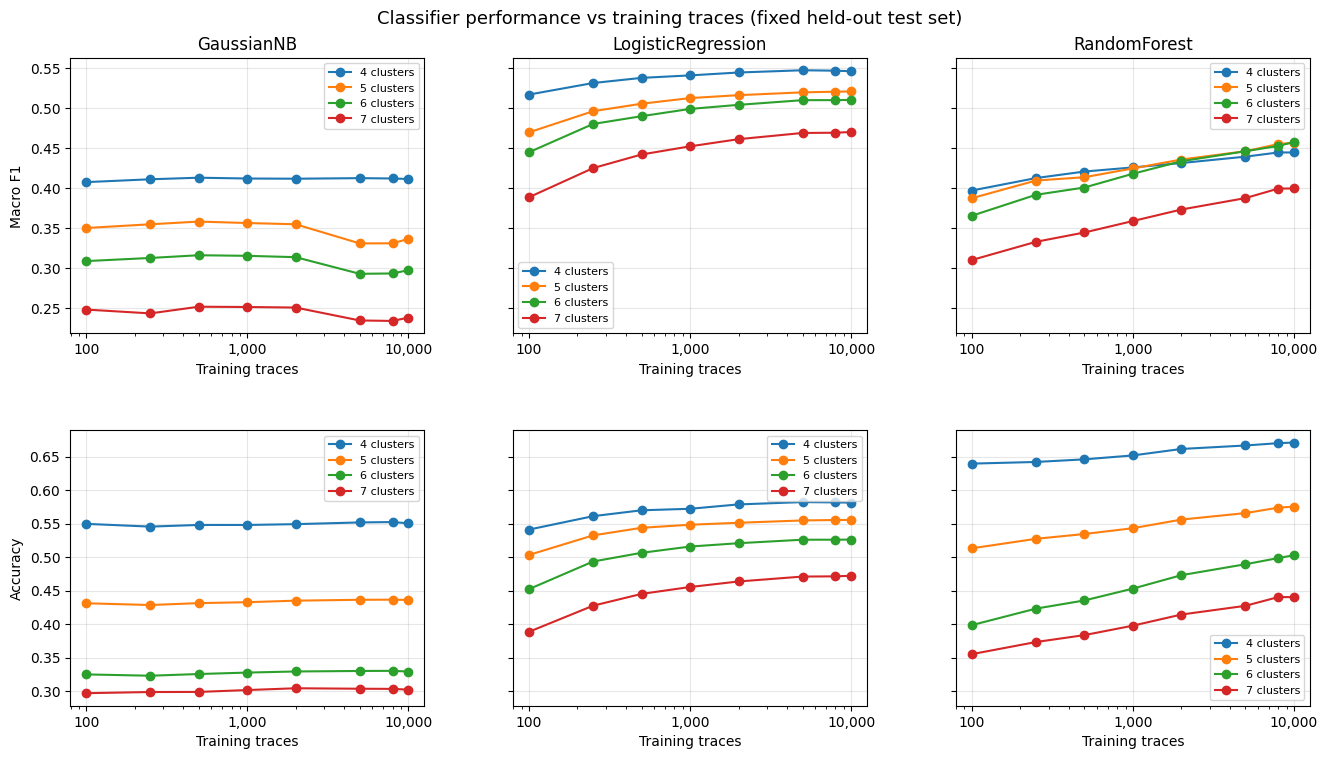

In [34]:
from matplotlib.ticker import FuncFormatter
# results_df = pd.read_csv('../data/classification_results_by_cluster.csv')  # uncomment to skip re-running

metrics     = [('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]
model_names = list(models.keys())
cluster_colors = {n: plt.cm.tab10(i) for i, n in enumerate(CLUSTER_RANGE)}

fig, axes = plt.subplots(len(metrics), len(model_names), figsize=(16, 8), sharey='row')

for row, (metric, metric_label) in enumerate(metrics):
    for col, model_name in enumerate(model_names):
        ax = axes[row][col]
        for n_clusters in CLUSTER_RANGE:
            sub = (results_df
                   [(results_df['model'] == model_name) &
                    (results_df['n_clusters'] == n_clusters)]
                   .sort_values('n_traces'))
            ax.plot(sub['n_traces'], sub[metric],
                    marker='o', label=f'{n_clusters} clusters',
                    color=cluster_colors[n_clusters])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.set_xlabel('Training traces')
        if col == 0:
            ax.set_ylabel(metric_label)
        if row == 0:
            ax.set_title(model_name)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Classifier performance vs training traces (fixed held-out test set)', fontsize=13)
plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.25)
plt.show()

In [35]:
TRACE_COUNTS  = [100, 250, 500, 1000, 2000, 5000, 8000, 10000]
CLUSTER_RANGE = range(4, 8)

metrics     = [('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]
model_names = list(models.keys())
cluster_colors = {n: plt.cm.tab10(i) for i, n in enumerate(CLUSTER_RANGE)}


### Pivot table — macro F1 at a glance

In [36]:
PIVOT_N_TRACES = 10000  # show results at max trace count

pivot = (
    results_df[results_df['n_traces'] == PIVOT_N_TRACES]
    .pivot(index='n_clusters', columns='model', values='macro_f1')
    .round(3)
)
pivot.index.name = 'n_clusters'
print(f"Macro F1 at n_traces={PIVOT_N_TRACES} (fixed test set):")
pivot

Macro F1 at n_traces=10000 (fixed test set):


model,GaussianNB,LogisticRegression,RandomForest
n_clusters,,,
4,0.412,0.546,0.445
5,0.337,0.521,0.457
6,0.298,0.510,0.458
7,0.238,0.470,0.400


### Inspect cluster memberships for a chosen n_clusters

Change `INSPECT_N` to any value in `CLUSTER_RANGE` to see what's in each cluster.

In [37]:
INSPECT_N = 4  # change this

print(f"Cluster memberships for n_clusters={INSPECT_N}:")
for cluster_id, grp in memberships[INSPECT_N].groupby('cluster'):
    print(f"  {cluster_id}: {grp['AA'].tolist()}")

Cluster memberships for n_clusters=4:
  1, negative: ['D', 'E']
  2, small: ['G', 'A', 'S', 'C']
  3, positive: ['R', 'K']
  4, other: ['F', 'H', 'M', 'P', 'V', 'L', 'Y', 'Q', 'N', 'T', 'I', 'W']


### Confusion matrix for a chosen n_clusters + model

Set `BEST_N` and `BEST_MODEL_NAME` based on what the summary plot shows.

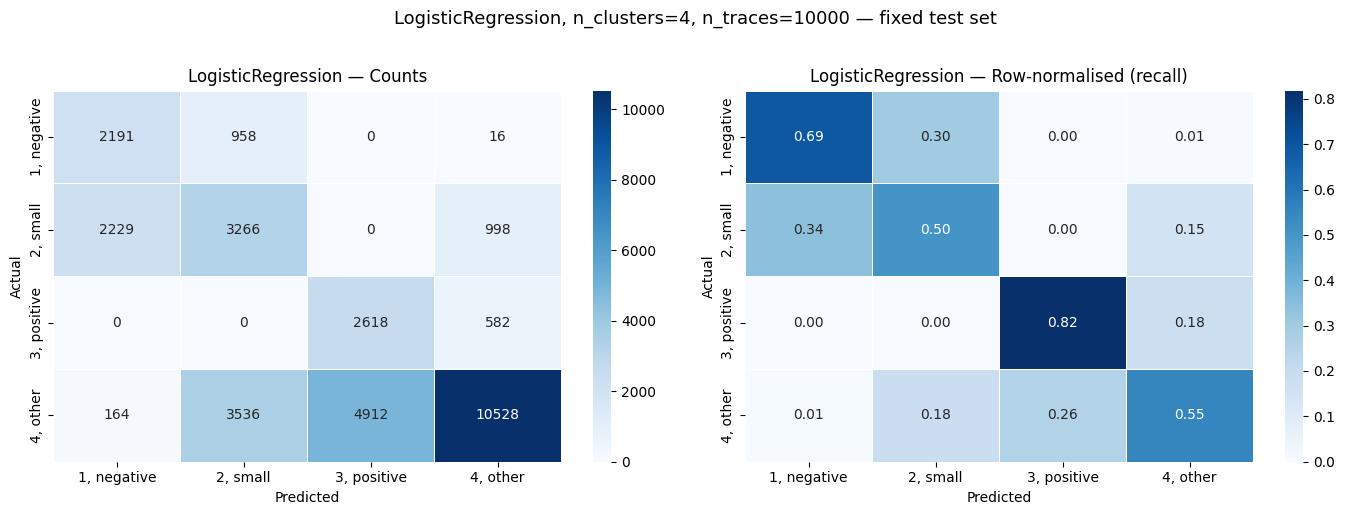

              precision    recall  f1-score   support

 1, negative       0.48      0.69      0.57      3165
    2, small       0.42      0.50      0.46      6493
 3, positive       0.35      0.82      0.49      3200
    4, other       0.87      0.55      0.67     19140

    accuracy                           0.58     31998
   macro avg       0.53      0.64      0.55     31998
weighted avg       0.69      0.58      0.60     31998



In [38]:
BEST_N        = 4
BEST_N_TRACES = 10000
BEST_MODEL_NAME = 'LogisticRegression'

raw_labels = fcluster(linkage_matrix, BEST_N, criterion='maxclust')
label_lookup = LABEL_MAP.get(BEST_N, {})
aa_to_cluster = {
    aa: label_lookup.get(int(raw_labels[i]), f'cluster_{raw_labels[i]}')
    for i, aa in enumerate(amino_acids)
}

train_df = all_train[all_train['trace_id'] < BEST_N_TRACES].copy()
train_df['cluster_label'] = train_df['amino_acid'].map(aa_to_cluster)
X_train = train_df[feature_cols].values
y_train = train_df['cluster_label'].values
train_mask = ~np.isnan(X_train).any(axis=1)
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_df = test_base_raw.copy()
test_df['cluster_label'] = test_df['amino_acid'].map(aa_to_cluster)
X_test = test_df[feature_cols].values
y_test = test_df['cluster_label'].values
test_mask = ~np.isnan(X_test).any(axis=1)
X_test, y_test = X_test[test_mask], y_test[test_mask]

best_model = clone(models[BEST_MODEL_NAME])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cluster_order = sorted(set(y_test))
cm_counts = confusion_matrix(y_test, y_pred, labels=cluster_order)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Counts', 'Row-normalised (recall)'],
    ['d', '.2f'],
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=cluster_order, yticklabels=cluster_order,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{BEST_MODEL_NAME} — {title}')

plt.suptitle(
    f'{BEST_MODEL_NAME}, n_clusters={BEST_N}, n_traces={BEST_N_TRACES} — fixed test set',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, labels=cluster_order, target_names=cluster_order))